In [18]:
from dotenv import load_dotenv
import os
from openai import OpenAI

load_dotenv(dotenv_path="../.env")

if os.environ.get("OPENAI_API_KEY"):
    print("OPENAI_API KEY is set")
else:
    raise ValueError("OPENAI_API_KEY is not set in environment variables")

from langchain_openai import ChatOpenAI
from langchain_core.prompts import  ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm_openai = ChatOpenAI(model="gpt-5-mini", temperature=0.9, max_tokens=1000)
llm_openai.invoke("What is the capital of California?").content


OPENAI_API KEY is set


'Sacramento. It’s the state capital of California, located in Northern California on the Sacramento River.'

In [19]:
###Tools

In [20]:
#Tool 1
from langchain_community.tools import DuckDuckGoSearchRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

duckduckgo_tool = DuckDuckGoSearchRun()
duckduckgo_tool.invoke("What is the capital of California?")

#Tool 2
wikipedia_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wikipedia_tool.invoke("What is the capital of India?")

#Tool - 3
from langchain_core.tools import tool
@tool
def enterprise_tool(query:str)->str:
    """This is a tool to send email to employees in the enterprise"""
    return f"Email sent"


In [21]:
ToolKit = [duckduckgo_tool,wikipedia_tool,enterprise_tool]

In [22]:
ToolKit

[DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text')),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'e:\\langchain_tutorial\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000)),
 StructuredTool(name='enterprise_tool', description='This is a tool to send email to employees in the enterprise', args_schema=<class 'langchain_core.utils.pydantic.enterprise_tool'>, func=<function enterprise_tool at 0x0000022F9A9996C0>)]

##React Agent

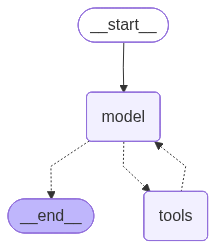

In [ ]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

model=ChatOpenAI(model="gpt-5-mini", temperature=0.9, max_tokens=1000)

ToolKit = [duckduckgo_tool, wikipedia_tool]
agent = create_agent(model=model, tools=ToolKit)
agent

In [26]:
example_query = "Tell me about today's weather in Minnesota Minnetonka and send an email to all employees about the same"

print("Starting agent stream...")
events = agent.stream(
    {"messages":[("user",example_query)]},
    stream_mode="values"
)
for event in events:
    print("Event received:")
    event["messages"][-1].pretty_print()


================================ Human Message =================================

Tell me about today's weather in Minnesota Minnetonka and send an email to all employees about the same
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_0MscmTLiZmIpVUb8HwS4mguT)
 Call ID: call_0MscmTLiZmIpVUb8HwS4mguT
  Args:
    query: Minnetonka MN weather today
================================= Tool Message =================================
Name: duckduckgo_search

Minnetonka, Minnesota - Current temperature and weather conditions. Detailed hourly weather forecast for today - including weather conditions, temperature, pressure, humidity, precipitation, dewpoint, wind, visibility, and UV index data. Minnetonka, MN - Weather forecast from Theweather.com. Weather conditions with updates on temperature, humidity, wind speed, snow, pressure, etc. for Minnetonka, Minnesota. Hourly Weather Minnetonka, Minnesota 55305 · as of 4:33 PM PDT It

Manually Binding LLM with tools

In [28]:
#Without binding

llm_openai.invoke("What is the latest news about stock market?").content

'I don’t have live internet access, so I can’t fetch real‑time headlines. I can, however:\n\n- Tell you how to get the very latest market news right now (best websites/apps and what to check), and\n- Summarize major market themes and drivers through mid‑2024 so you have context, or\n- Pull together a tailored update if you tell me which market (U.S., Europe, Asia) or specific indices/tickers you care about.\n\nWhich would you like?\n\nIf you want the fastest ways to see “latest” right now:\n- Check real‑time sites/apps: Bloomberg, Reuters, CNBC, WSJ Markets, Financial Times, MarketWatch, Seeking Alpha, TradingView.  \n- For prices/futures: Google Finance, Yahoo Finance, TradingView, or your broker app. Look at S&P 500, Nasdaq, Dow, Russell 2000, and premarket futures.  \n- For macro drivers: U.S. Treasury yields (2yr/10yr), U.S. dollar index (DXY), WTI crude, and VIX (volatility).  \n- For company moves: earnings calendar, SEC filings, and company press releases (CNBC/Reuters often sum

In [30]:
#with Binding
llm_binding=llm_openai.bind_tools(ToolKit)
llm_binding.invoke("What is the latest news about stock market?")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 171, 'prompt_tokens': 248, 'total_tokens': 419, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DWbKepmR2YcXBaVL9wLhBJOWbTScX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019da965-dd89-7271-a69b-cd0bab08a9a3-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'latest stock market news today major indices S&P 500 Nasdaq Dow Fed earnings market movers headline'}, 'id': 'call_QTz8yCTSf3y35hBiIxvvrI9o', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 248, 'output_tokens': 171, 'total_tokens': 419, 'input_token_details': {'au